Step 1: Install libraries

In [116]:
!pip install pandas

Step 2: Import files

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [118]:
df = pd.read_csv('insurance.csv')

Step 3: Data Overview

In [119]:
df.shape

(1338, 7)

In [120]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [121]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [122]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Step 4: Descriptive Analysis

In [123]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Categorical breakdown

In [150]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [151]:
df['sex'].value_counts(normalize = 'True')

sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64

In [126]:
categorical_counts = df.select_dtypes(include = ['object']).apply(pd.Series.value_counts)

categorical_counts


,sex,smoker,region
female,662.0,NaN,NaN
male,676.0,NaN,NaN
no,NaN,1064.0,NaN
northeast,NaN,NaN,324.0
northwest,NaN,NaN,325.0
southeast,NaN,NaN,364.0
southwest,NaN,NaN,325.0
yes,NaN,274.0,NaN


Step 5: Distribution & Outlier Analysis

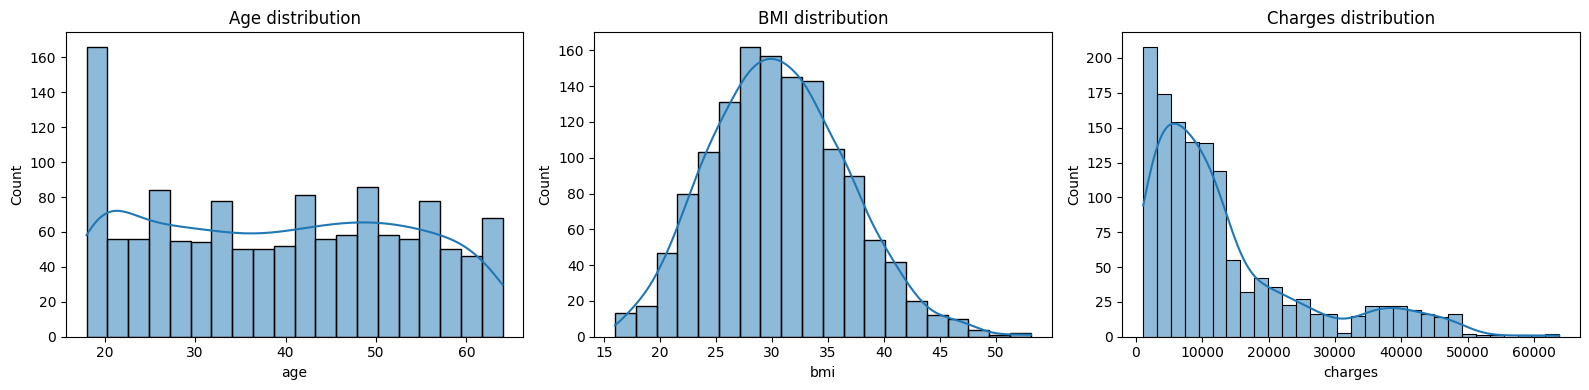

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age distribution')

sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('BMI distribution')

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Charges distribution')

plt.tight_layout()
plt.show()

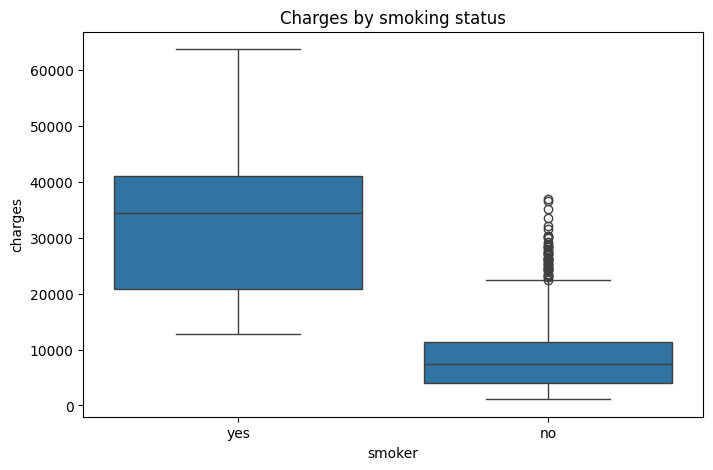

In [128]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by smoking status')
plt.show()

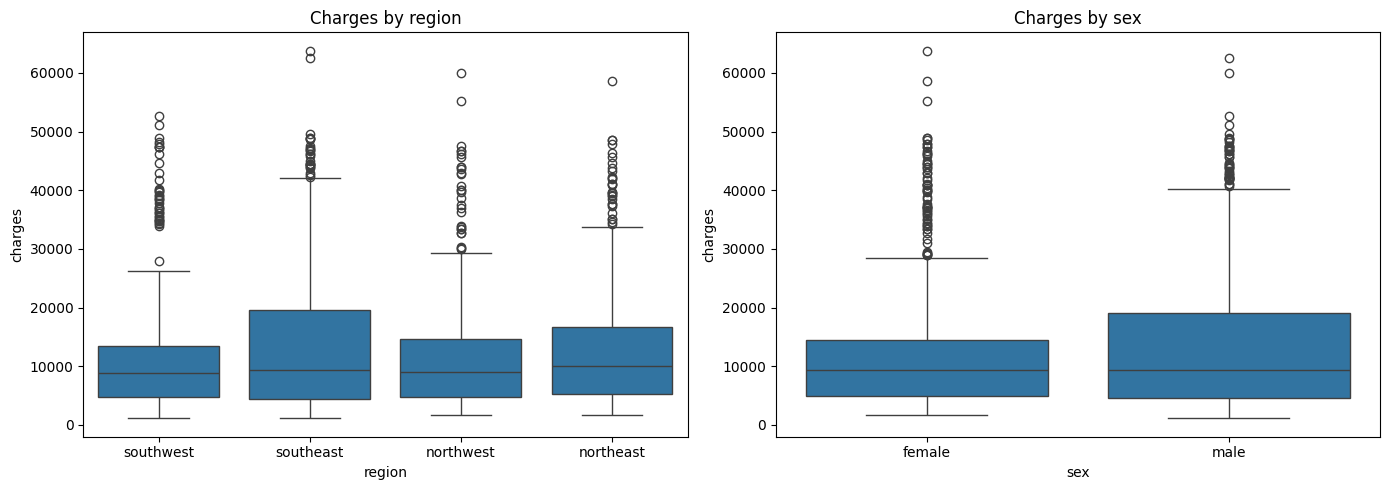

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='region', y='charges', ax=axes[0])
axes[0].set_title('Charges by region')

sns.boxplot(data=df, x='sex', y='charges', ax=axes[1])
axes[1].set_title('Charges by sex')

plt.tight_layout()
plt.show()

Step 6: Correlation Analysis

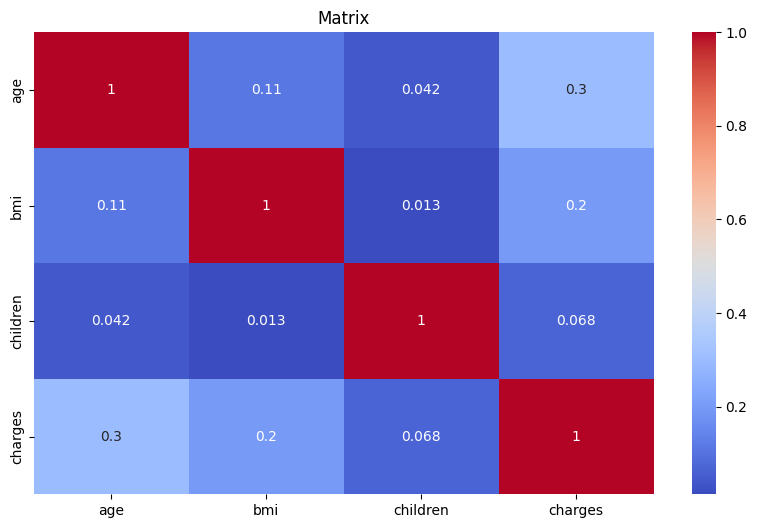

In [130]:
plt.figure(figsize = (10,6))

numeric_data = df.select_dtypes(include = [np.number])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm')
plt.title('Matrix')
plt.show()

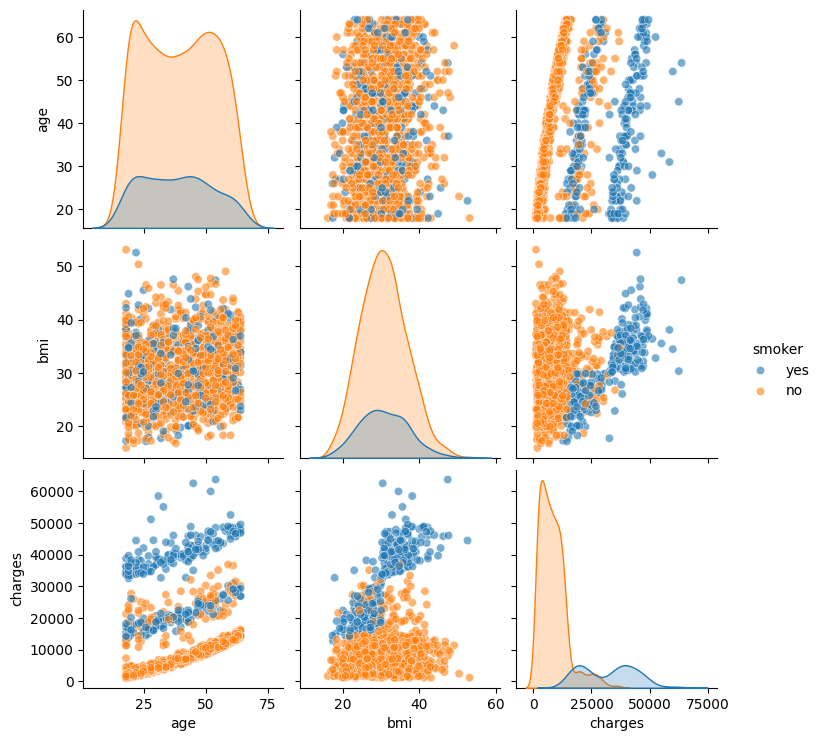

In [131]:
sns.pairplot(df, vars = ['age', 'bmi', 'charges'], hue = 'smoker', plot_kws={'alpha': 0.6})
plt.show()

Step 7: Group Comparisons & Statistical Testing

In [132]:
avg_charges_smokers = df.groupby('smoker')['charges'].mean()

print(avg_charges_smokers)



smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


In [133]:
avg_charges_region = df.groupby('region')['charges'].mean()
print(avg_charges_region)

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


In [134]:
smoker_charges = df.loc[df['smoker'] == 'yes', 'charges']
nonsmoker_charges = df.loc[df['smoker'] == 'no', 'charges']

t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)
print(f"Welch's t-test — smoker vs non-smoker charges")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")

Welch's t-test — smoker vs non-smoker charges
t-statistic: 32.75, p-value: 5.89e-103


In [135]:
region_groups = [group['charges'].values for _, group in df.groupby('region')]
f_stat, p_value_region = stats.f_oneway(*region_groups)
print(f'One-way Anova - charges across regions')
print(f'F-statistic: {f_stat:.2f}, p-value: {p_value_region:.4f})')

One-way Anova - charges across regions
F-statistic: 2.97, p-value: 0.0309)


Step 8: Predictive Modelling

In [136]:
# Encode feautures & split data

from sklearn.model_selection import train_test_split

model_df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
x = model_df.drop(columns=['charges'])
y = model_df['charges']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Train size: {x_train.shape[0]}, Test size: {x_test.shape[0]}')
x.head()



Train size: 1070, Test size: 268


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [137]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr = lr.predict(x_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f'Linear Regression - R2: {r2_lr:.3f}')
print(f'RMSE: ${rmse_lr:,.0f}')
print(f'MAE: ${mae_lr:,.0f}')


Linear Regression - R2: 0.784
RMSE: $5,796
MAE: $4,181


In [138]:
# Testing the smoker * BMI interaction

import statsmodels.formula.api as smf

df['bmi_centered'] = df['bmi'] - df['bmi'].mean()

print(f"Mean BMI: {df['bmi'].mean():.2f}")
print(f"Mean-centred BMI range: {df['bmi_centered'].min():.2f} to {df['bmi_centered'].max():.2f}")

Mean BMI: 30.66
Mean-centred BMI range: -14.70 to 22.47


In [139]:
df['smoker'] = pd.Categorical(
    df['smoker'],
    categories=['no', 'yes']
)

df['sex'] = pd.Categorical(
    df['sex'],
    categories=['female', 'male']
)

df['region'] = pd.Categorical(
    df['region'],
    categories=['northeast', 'northwest', 'southeast', 'southwest']
)

In [140]:
interaction_model = smf.ols(
    'charges ~ age + bmi_centered + children + C(sex) + '
    'C(smoker) + C(region) + bmi_centered:C(smoker)',
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     780.0
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:46:04   Log-Likelihood:                -13248.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1328   BIC:                         2.657e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [141]:
results = pd.DataFrame({
    'Coefficient': interaction_model.params,
    'P-value': interaction_model.pvalues
})

results

,Coefficient,P-value
Intercept,-1501.856724,2.743697e-03
C(sex)[T.male],-500.145974,6.079248e-02
C(smoker)[T.yes],23834.626405,0.000000e+00
C(region)[T.northwest],-585.478045,1.244691e-01
C(region)[T.southeast],-1210.131197,1.604129e-03
C(region)[T.southwest],-1231.107735,1.308588e-03
age,263.620228,1.074400e-133
bmi_centered,23.532853,3.581414e-01
bmi_centered:C(smoker)[T.yes],1443.096400,1.819886e-131
children,516.403404,3.058613e-06


In [142]:
bmi_range = np.linspace(
    df['bmi'].min(),
    df['bmi'].max(),
    100
)

plot_df = pd.DataFrame({
    'bmi': np.tile(bmi_range, 2),
    'bmi_centered': np.tile(
        bmi_range - df['bmi'].mean(),
        2
    ),
    'smoker': ['no'] * 100 + ['yes'] * 100,
    'age': df['age'].mean(),
    'children': df['children'].mean(),
    'sex': 'female',
    'region': 'northeast'
})

plot_df['predicted_charges'] = interaction_model.predict(plot_df)

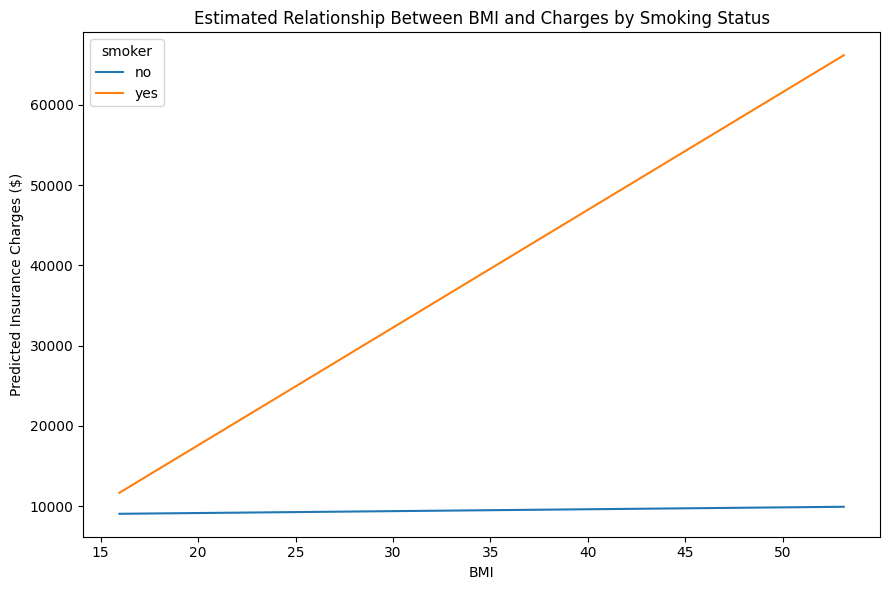

In [143]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=plot_df,
    x='bmi',
    y='predicted_charges',
    hue='smoker'
)

plt.title('Estimated Relationship Between BMI and Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Predicted Insurance Charges ($)')
plt.tight_layout()
plt.show()

In [144]:
# Random forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'Random Forest — R2: {r2_rf:.3f}')
print(f'RMSE: ${rmse_rf:,.0f}')
print(f'MAE: ${mae_rf:,.0f}')

Random Forest — R2: 0.874
RMSE: $4,421
MAE: $2,549


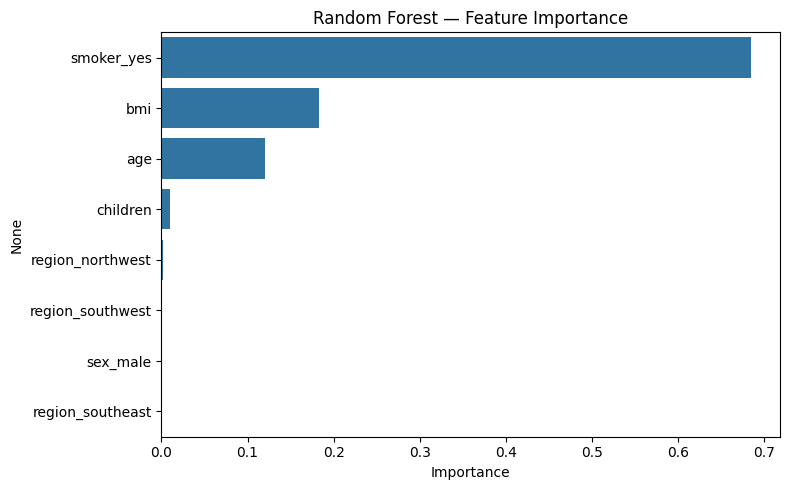

In [145]:
feature_importance = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [146]:
# Model Comparison

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [r2_lr, r2_rf],
    'RMSE ($)': [rmse_lr, rmse_rf],
    'MAE ($)': [mae_lr, mae_rf]
})
results

,Model,R2,RMSE ($),MAE ($)
0,Linear Regression,0.783593,5796.284659,4181.194474
1,Random Forest,0.874128,4420.574960,2548.843155


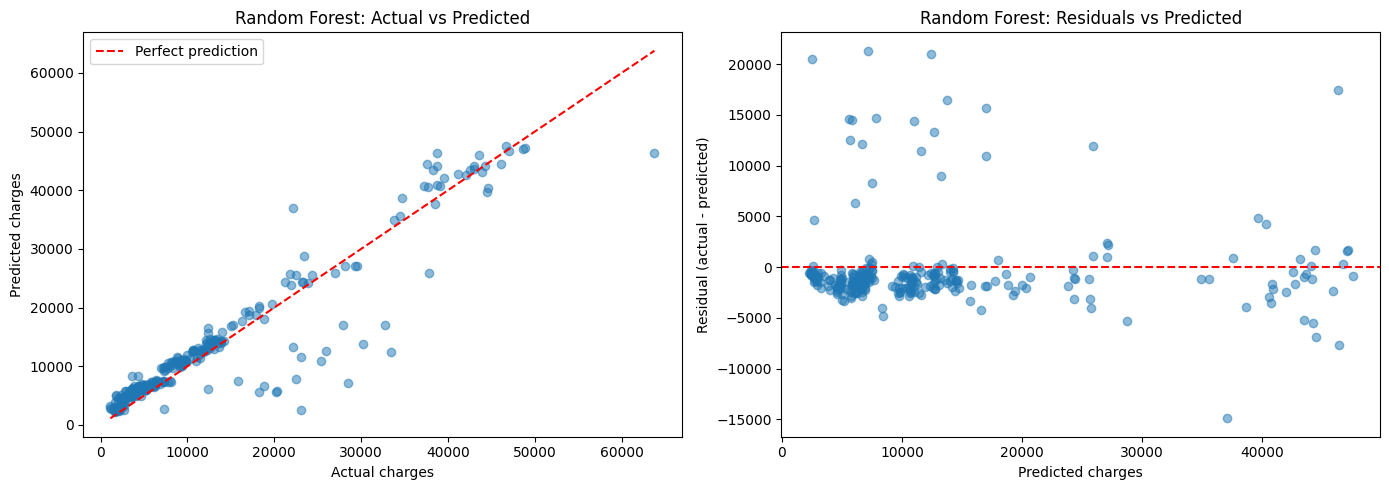

In [147]:
# Residual Diagnostics

residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.5)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual charges')
axes[0].set_ylabel('Predicted charges')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted charges')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Random Forest: Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [148]:
# Cross validation

from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(LinearRegression(), x, y, cv=cv, scoring='r2')
cv_scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42), x, y, cv=cv, scoring='r2'
)

print(f"Linear Regression — 5-fold CV R2:   {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std():.3f})")
print(f"Random Forest — 5-fold CV R2:       {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std():.3f})")

Linear Regression — 5-fold CV R2:   0.740 (+/- 0.058)
Random Forest — 5-fold CV R2:       0.852 (+/- 0.032)


In [149]:
# Does a log_transformed target help?

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_log = LinearRegression().fit(x_train, y_train_log)
y_pred_lr_log = np.expm1(lr_log.predict(x_test))

rf_log = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42).fit(x_train, y_train_log)
y_pred_rf_log = np.expm1(rf_log.predict(x_test))

log_results = pd.DataFrame({
    'Model': ['Linear Regression (log target)', 'Random Forest (log target)'],
    'R2': [r2_score(y_test, y_pred_lr_log), r2_score(y_test, y_pred_rf_log)],
    'RMSE ($)': [np.sqrt(mean_squared_error(y_test, y_pred_lr_log)), np.sqrt(mean_squared_error(y_test, y_pred_rf_log))],
    'MAE ($)': [mean_absolute_error(y_test, y_pred_lr_log), mean_absolute_error(y_test, y_pred_rf_log)]
})
pd.concat([results, log_results], ignore_index=True)

,Model,R2,RMSE ($),MAE ($)
0,Linear Regression,0.783593,5796.284659,4181.194474
1,Random Forest,0.874128,4420.574960,2548.843155
2,Linear Regression (log target),0.606698,7814.064026,3888.443159
3,Random Forest (log target),0.876106,4385.702868,2088.371468
